In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import math
from matplotlib import rcParams
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
'''rcParams['font.family']='Liberation Serif'
rcParams['font.weight']='bold'
rcParams['font.size']=15
rcParams['axes.labelweight']='bold'
rcParams['axes.titleweight']='bold'
rcParams['xtick.labelsize']=15
rcParams['ytick.labelsize']=15'''
df = pd.read_csv("spambase_csv_Kaggle.csv")
df

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [2]:

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nMissing values per column (top 10):\n", df.isna().sum().sort_values(ascending=False).head(10))


Shape: (4601, 58)

Head:
    word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00            0.00  ...  

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\n=== Column Types ===")
print("Numeric columns:", numeric_cols)
print("Categorical/bool columns:", cat_cols)


=== Column Types ===
Numeric columns: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 'char_f

In [4]:
print("\n Missing Values (count & %)")
miss_count = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": miss_count, "missing_pct": miss_pct})
print(missing_table[missing_table["missing_count"] > 0])

dup = df.duplicated().sum()
print(f"\n=== Duplicates ===\nDuplicates: {dup}")



 Missing Values (count & %)
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

=== Duplicates ===
Duplicates: 391


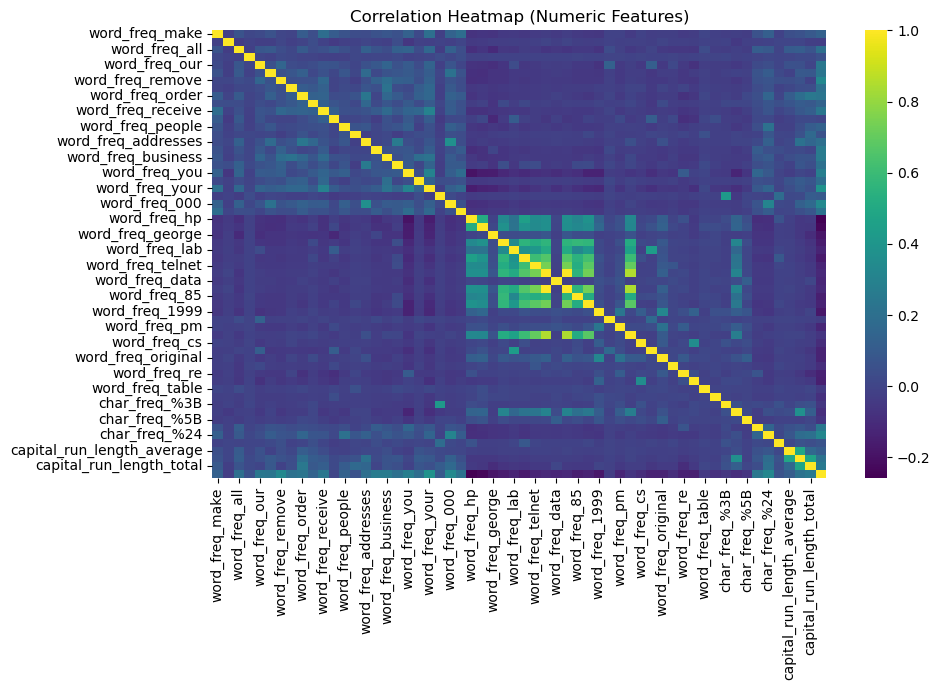

In [5]:
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig( "assign2_1.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()


In [6]:
def detect_target_column(dataframe: pd.DataFrame) -> str:
    # Common names
    for c in ["label", "target", "class", "spam", "y"]:
        if c in dataframe.columns:
            return c

    # Otherwise: choose a binary column with {0,1} and low unique count; prefer last column
    candidates = []
    for c in dataframe.columns:
        uniq = dataframe[c].dropna().unique()
        if len(uniq) == 2 and set(uniq).issubset({0, 1}):
            candidates.append(c)

    if not candidates:
        # fallback: last column
        return dataframe.columns[-1]

    # prefer last column if it's a candidate
    if dataframe.columns[-1] in candidates:
        return dataframe.columns[-1]

    return candidates[0]

target_col = detect_target_column(df)
print("\nDetected target column:", target_col)



Detected target column: class


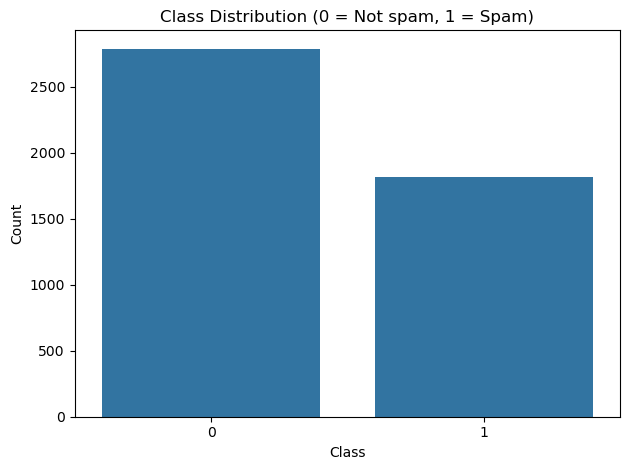

In [7]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X = X.fillna(X.median(numeric_only=True))

if y.isna().any():
    y = y.fillna(y.mode().iloc[0])
plt.figure()
sns.countplot(x=y)
plt.title("Class Distribution (0 = Not spam, 1 = Spam)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig( "assign2_2.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

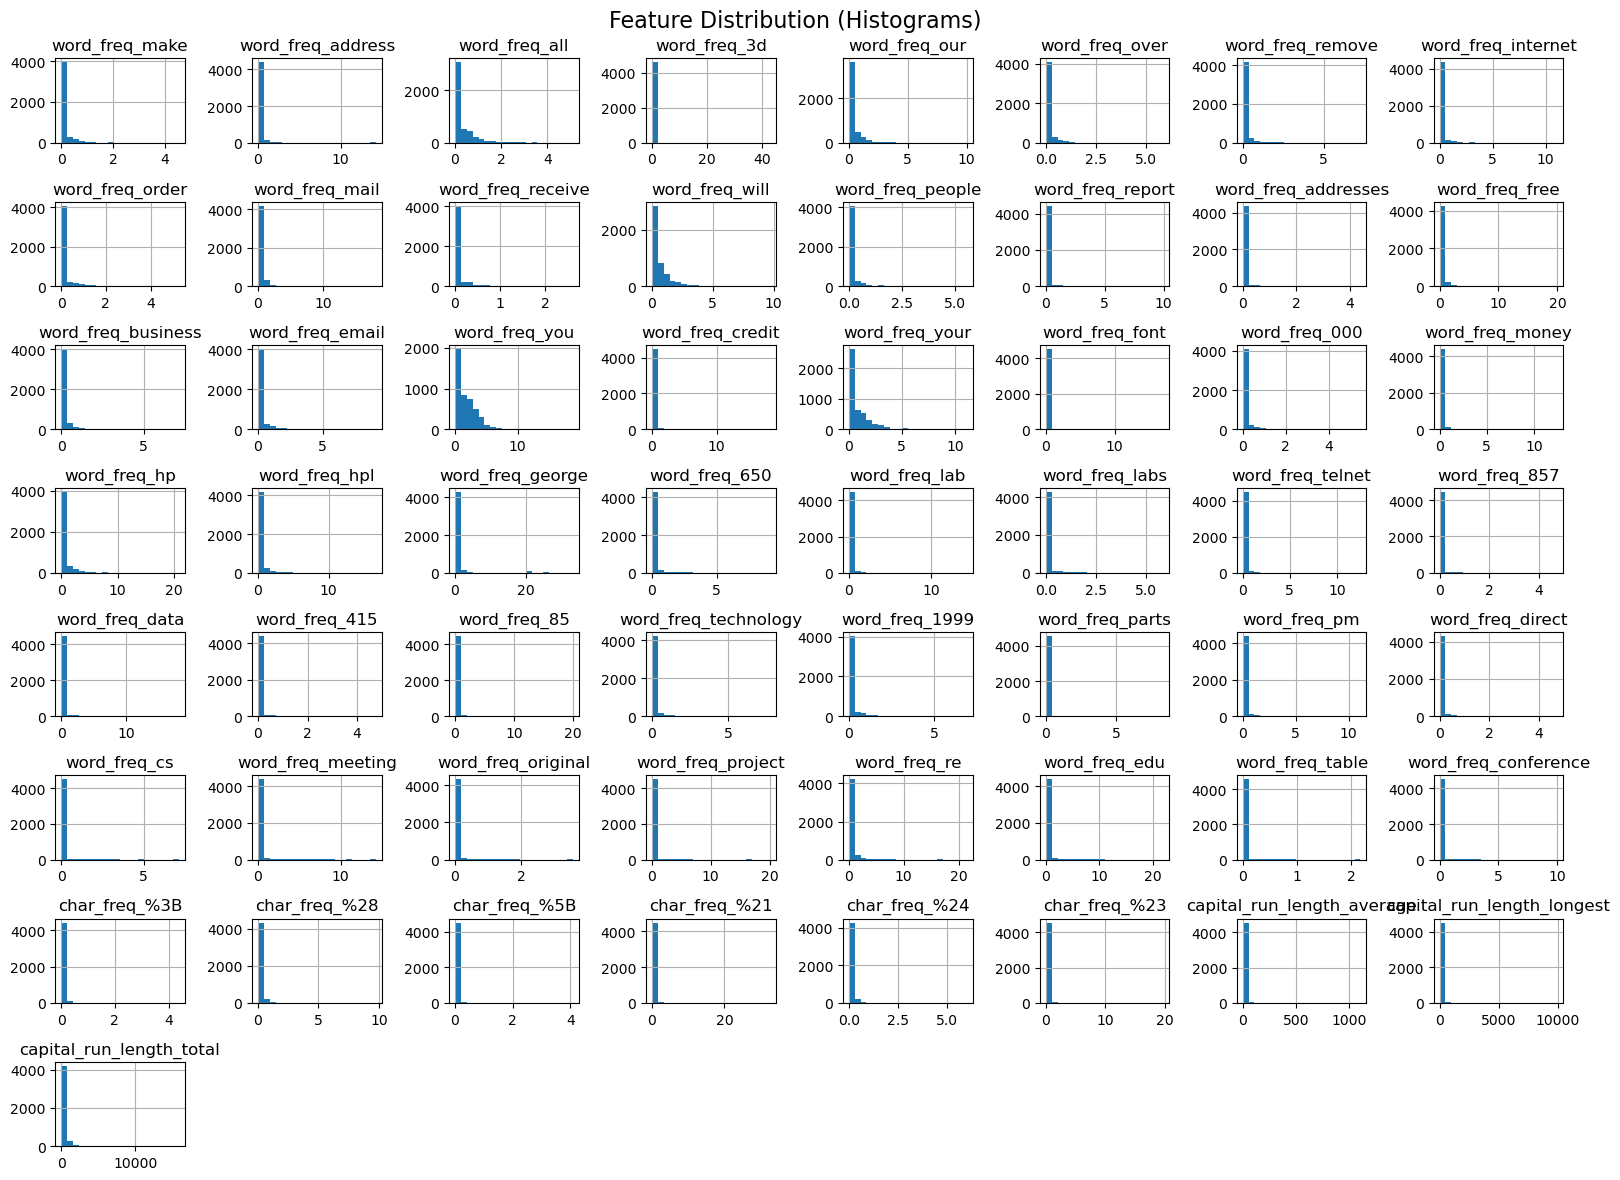

In [8]:
X.hist(bins=20, figsize=(16, 12))
plt.suptitle("Feature Distribution (Histograms)", fontsize=16)
plt.tight_layout()
plt.savefig( "assign2_3.eps", format="eps", dpi=600, bbox_inches="tight" ) 
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


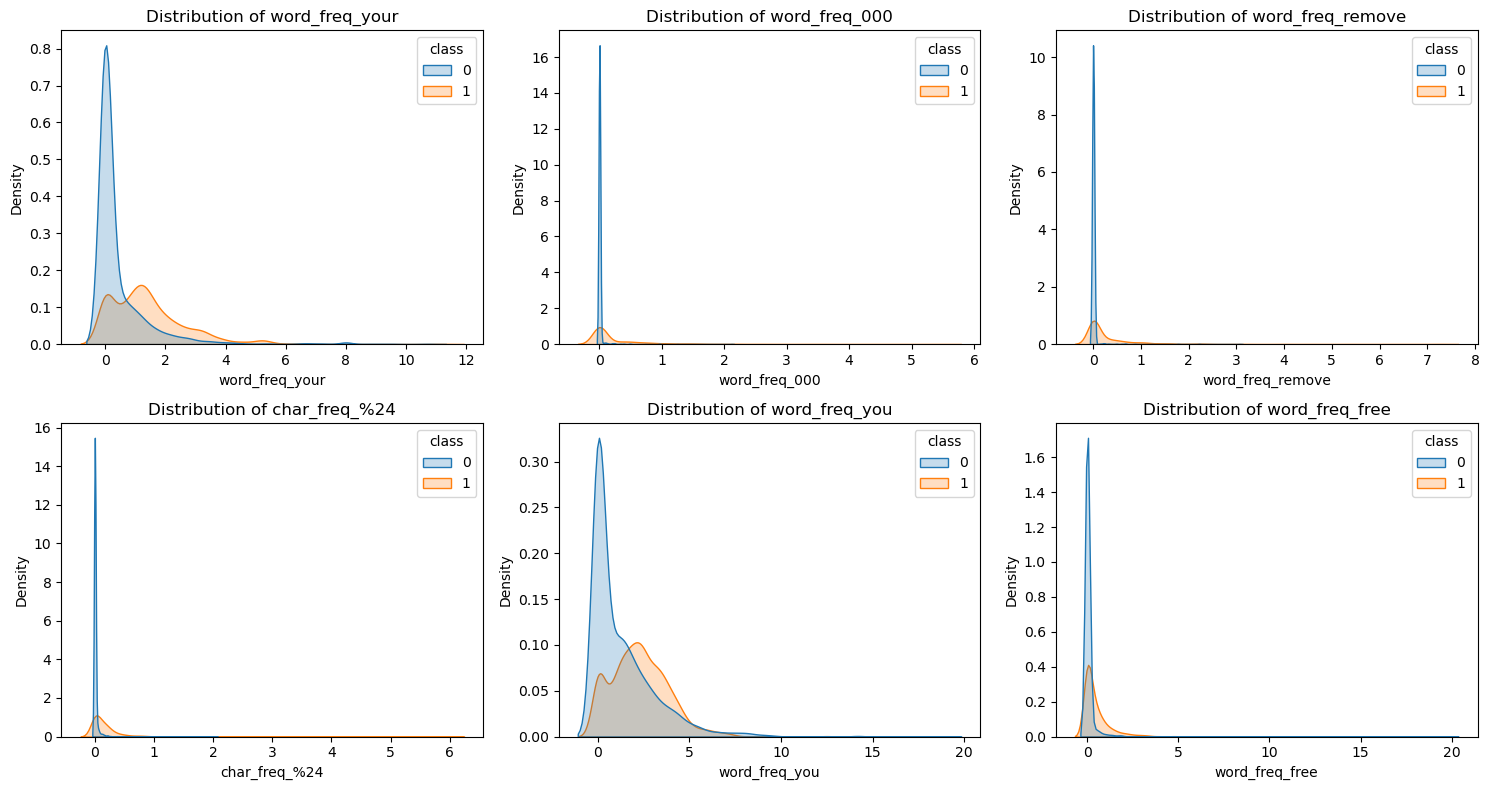

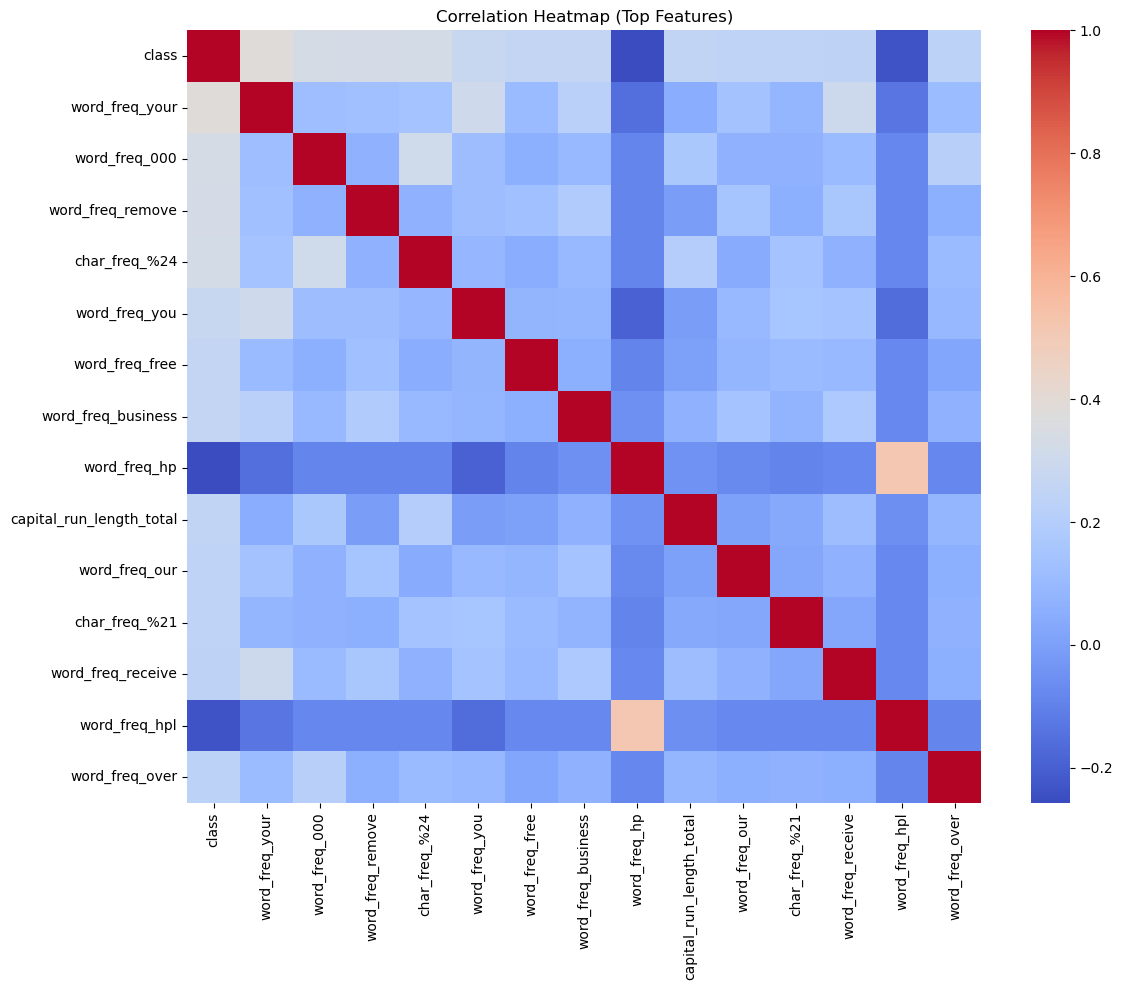

In [9]:

# 3. Feature Distribution by Class (KDE plots)

df_corr = df.corr(numeric_only=True)[target_col].abs().sort_values(ascending=False)
top_features = df_corr.index[1:7]  # skip target itself

plt.figure(figsize=(15, 8))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df, x=feature, hue=target_col, fill=True)
    plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.savefig( "assign2_4.eps", format="eps", dpi=600, bbox_inches="tight" ) 
plt.show()
# 5. Correlation Heatmap (Top Features)

top_corr_features = df_corr.head(15).index

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_corr_features].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Top Features)")
plt.tight_layout()
plt.savefig( "assign2_5.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()


In [10]:
#Normalisation
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_normalized = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

df_normalized = pd.concat([X_normalized, y.reset_index(drop=True)], axis=1)

print("\nNormalized dataset preview:")
print(df_normalized.head())

print("\nFeature range after normalization:")
print(X_normalized.describe().loc[["min", "max"]])


Normalized dataset preview:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0        0.000000           0.044818       0.125490           0.0   
1        0.046256           0.019608       0.098039           0.0   
2        0.013216           0.000000       0.139216           0.0   
3        0.000000           0.000000       0.000000           0.0   
4        0.000000           0.000000       0.000000           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0          0.032        0.000000          0.000000            0.000000   
1          0.014        0.047619          0.028886            0.006301   
2          0.123        0.032313          0.026135            0.010801   
3          0.063        0.000000          0.042641            0.056706   
4          0.063        0.000000          0.042641            0.056706   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0         0.000000        0.000000  ..

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


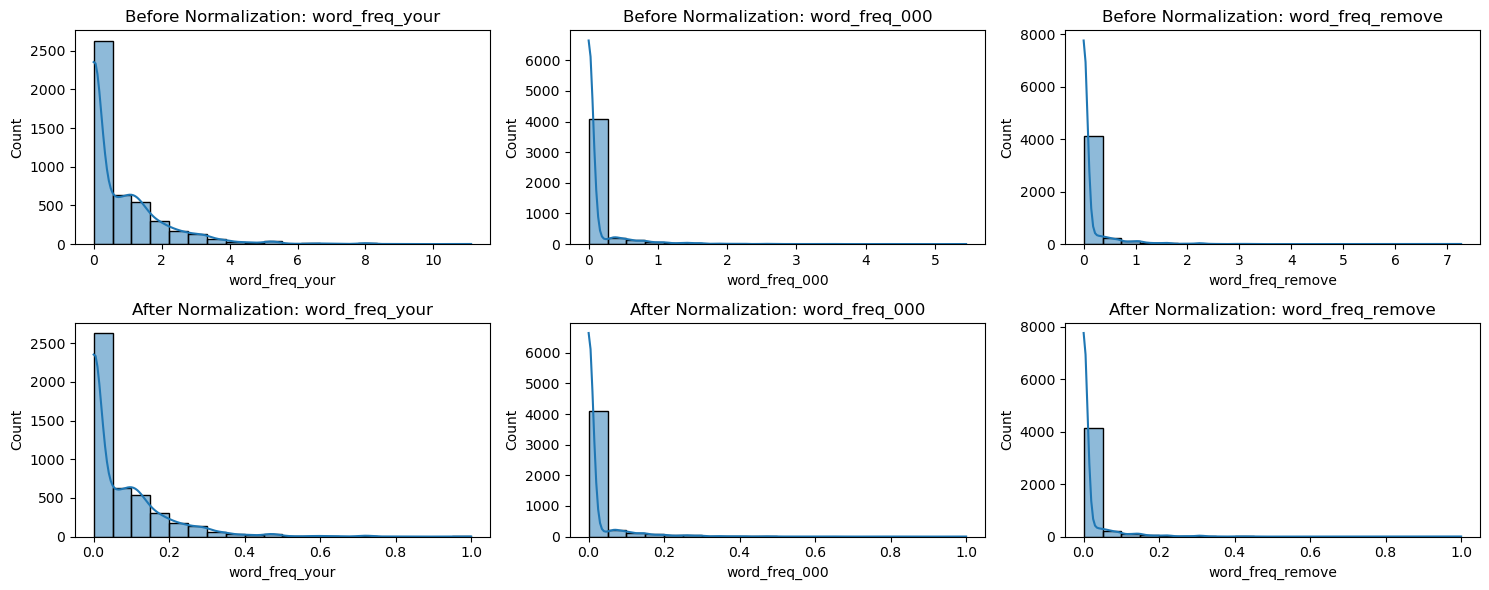

In [11]:
features_to_plot = top_features[:3] 

plt.figure(figsize=(15, 6))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(X[feature], bins=20, kde=True)
    plt.title(f"Before Normalization: {feature}")

    plt.subplot(2, 3, i + 3)
    sns.histplot(X_normalized[feature], bins=20, kde=True)
    plt.title(f"After Normalization: {feature}")

plt.tight_layout()
plt.savefig( "assign2_6.eps", format="eps", dpi=600, bbox_inches="tight" ) 
plt.show()

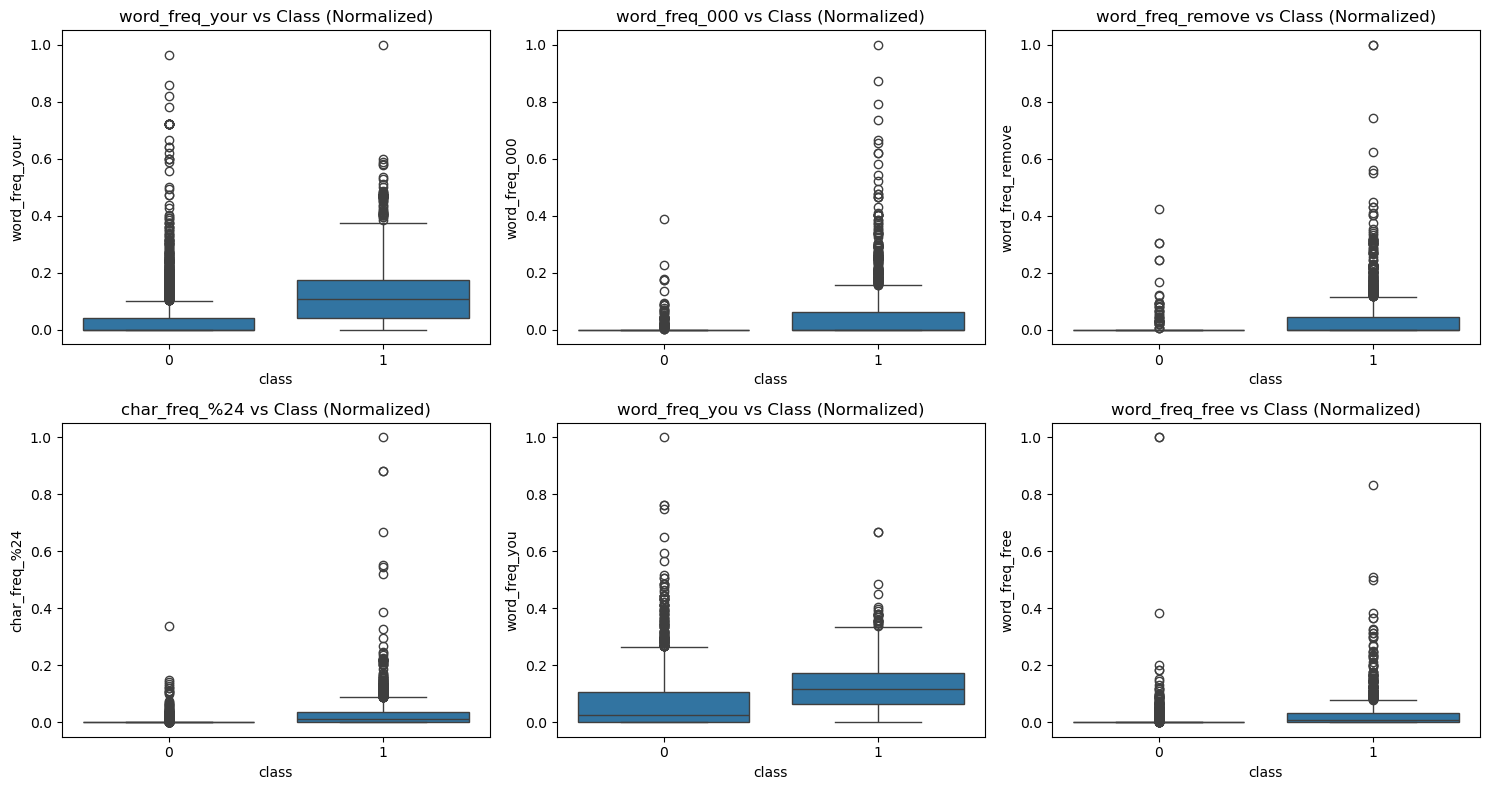

In [12]:
plt.figure(figsize=(15, 8))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=y, y=X_normalized[feature])
    plt.title(f"{feature} vs Class (Normalized)")
plt.tight_layout()
plt.show()


In [13]:
#Standardisation- Z-Score
from sklearn.preprocessing import StandardScaler


In [14]:
#Split Data into train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,     
    y,                
    test_size=0.2,    
    random_state=42,
    stratify=y        
)
std_scaler = StandardScaler()

X_standardized = std_scaler.fit_transform(X_train)
X_test_scaled = std_scaler.transform(X_test)
print("Training set shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

minmaxscaler = MinMaxScaler()

X_train_mm = std_scaler.fit_transform(X_train)
X_test_mm = std_scaler.transform(X_test)

Training set shape:
X_train: (3680, 57)
y_train: (3680,)

Testing set shape:
X_test: (921, 57)
y_test: (921,)


Time taken:  0.027771711349487305
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92       558
           1       0.94      0.78      0.85       363

    accuracy                           0.89       921
   macro avg       0.91      0.87      0.88       921
weighted avg       0.90      0.89      0.89       921

Specificity: 0.9695340501792115


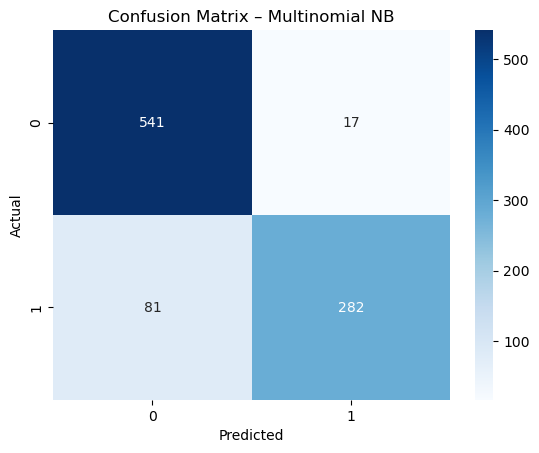

In [15]:
mnb = MultinomialNB()
start=time.time()
mnb=MultinomialNB()
mnb.fit(X_train,y_train)
ttmnb=time.time()-start
y_pred=mnb.predict(X_test)
print("Time taken: ",ttmnb)
print("Classification Report:\n",classification_report(y_test, y_pred))
cm = confusion_matrix(y_test,y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
print("Specificity:", specificity)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Multinomial NB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig( "assign2_7.eps", format="eps", dpi=600, bbox_inches="tight" ) 
plt.show()

Time taken:  0.00918722152709961
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.75      0.84       558
           1       0.71      0.96      0.82       363

    accuracy                           0.83       921
   macro avg       0.84      0.85      0.83       921
weighted avg       0.87      0.83      0.83       921

Specificity: 0.7508960573476703


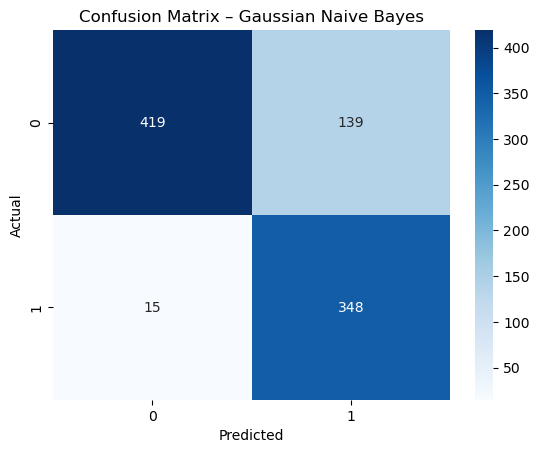

In [16]:
gnb = GaussianNB()
start=time.time()
gnb=GaussianNB()
gnb.fit(X_standardized,y_train)
ttgnb=time.time()-start
y_pred=gnb.predict(X_test_scaled)
print("Time taken: ",ttgnb)
print("Classification Report:\n",classification_report(y_test, y_pred))
cm = confusion_matrix(y_test,y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
print("Specificity:", specificity)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig( "assign2_8.eps", format="eps", dpi=600, bbox_inches="tight" ) 
plt.show()

Time taken:  0.015288829803466797
Classification Report:               precision    recall  f1-score   support

           0       0.89      0.92      0.90       558
           1       0.87      0.82      0.84       363

    accuracy                           0.88       921
   macro avg       0.88      0.87      0.87       921
weighted avg       0.88      0.88      0.88       921

Specificity: 0.9193548387096774


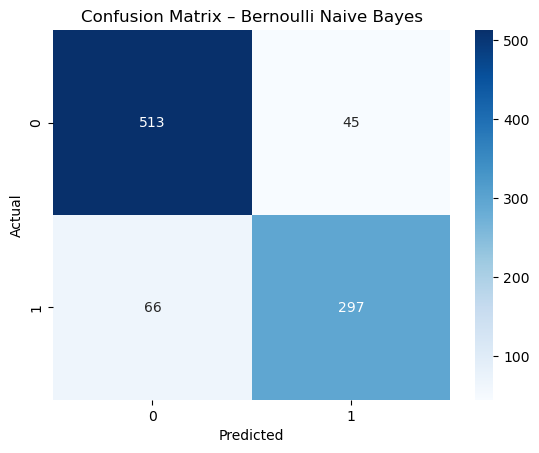

In [17]:
bnb = BernoulliNB()
start=time.time()
bnb=BernoulliNB()
bnb.fit(X_train,y_train)
ttbnb=time.time()-start
y_pred=bnb.predict(X_test)
print("Time taken: ",ttbnb)
print("Classification Report:",classification_report(y_test, y_pred))
cm = confusion_matrix(y_test,y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
print("Specificity:", specificity)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Bernoulli Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig( "assign2_9.eps", format="eps", dpi=600, bbox_inches="tight" ) 
plt.show()

In [18]:
y_prob_gnb=gnb.predict_proba(X_test_scaled)[:,1]
y_prob_mnb=mnb.predict_proba(X_test)[:,1]
y_prob_bnb=bnb.predict_proba(X_test)[:,1]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


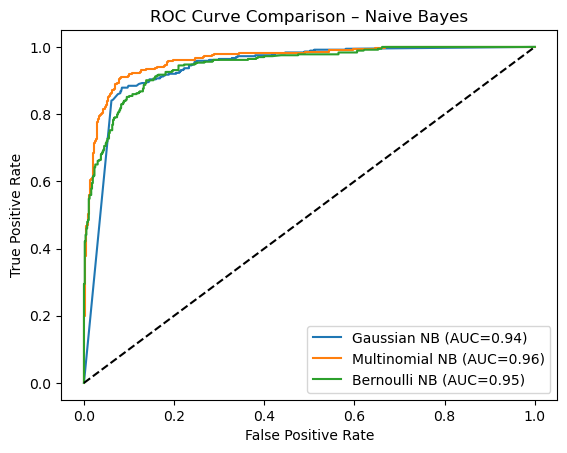

In [19]:
fpr_gnb,tpr_gnb,_=roc_curve(y_test,y_prob_gnb)
fpr_mnb,tpr_mnb,_=roc_curve(y_test,y_prob_mnb)
fpr_bnb,tpr_bnb,_=roc_curve(y_test,y_prob_bnb)
auc_gnb=auc(fpr_gnb,tpr_gnb)
auc_mnb=auc(fpr_mnb,tpr_mnb)
auc_bnb=auc(fpr_bnb,tpr_bnb)
plt.plot(fpr_gnb,tpr_gnb,label=f'Gaussian NB (AUC={auc_gnb:.2f})')
plt.plot(fpr_mnb,tpr_mnb,label=f'Multinomial NB (AUC={auc_mnb:.2f})')
plt.plot(fpr_bnb,tpr_bnb,label=f'Bernoulli NB (AUC={auc_bnb:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison – Naive Bayes")
plt.legend()
plt.savefig( "assign2_10.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [20]:
knn = KNeighborsClassifier()
knn.fit(X_standardized,y_train)
y_pred_knn = knn.predict(X_test_mm)

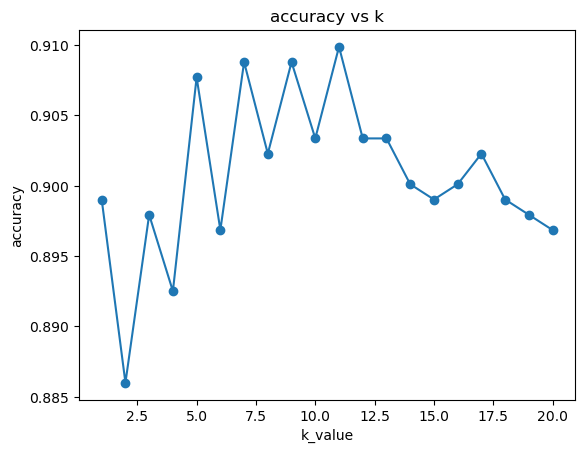

In [21]:
k_values = range(1,21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train_mm,y_train)
    accuracies.append(knn.score(X_test_mm,y_test))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k_value')
plt.ylabel('accuracy')
plt.title('accuracy vs k')
plt.savefig( "assign2_11.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [22]:
#Stratified 5-fold
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores_base = cross_val_score(
    knn,
    X_train_mm,
    y_train,
    cv=skf,
    scoring='accuracy'
)
print("Base KNN CV Accuracy: ",cv_scores_base.mean())


Base KNN CV Accuracy:  0.8926630434782608


In [23]:
param_grid = {
    'n_neighbors': list(range(1, 31, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    knn,
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_mm, y_train)
print("Grid Best Params:", grid.best_params_)
print("Grid Best CV Accuracy:", grid.best_score_)


Grid Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Grid Best CV Accuracy: 0.9252717391304348


In [24]:
#RANDOMIZED SEARCH
from scipy.stats import randint
param_dist = {
    'n_neighbors': randint(1, 30),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
rand = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=15,
    cv=skf,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
rand.fit(X_train_mm, y_train)
print("Random Best Params:", rand.best_params_)
print("Random Best CV Accuracy:", rand.best_score_)


Random Best Params: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Random Best CV Accuracy: 0.9241847826086957


In [25]:
#Final KNN Model
best_params = grid.best_params_

knn_final = KNeighborsClassifier(
    n_neighbors = best_params['n_neighbors'],
    weights = best_params['weights'],
    metric = best_params['metric']
)

knn_final.fit(X_train_mm, y_train)
y_pred_final = knn_final.predict(X_test_mm)

from sklearn.metrics import confusion_matrix, roc_curve, auc

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)
    specificity = tn / (tn + fp)
    fpr = fp / (fp + tn)
    return accuracy, precision, recall, f1, specificity, fpr, cm

In [26]:
start = time.time()
knn_final.fit(X_train_mm, y_train)
train_time = time.time() - start

start = time.time()
y_pred_knn = knn_final.predict(X_test_mm)
pred_time = time.time() - start

acc, prec, rec, f1, spec, fpr, cm = compute_metrics(y_test, y_pred_knn)

print("Final KNN Metrics")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("Specificity:", spec)
print("False Positive Rate:", fpr)
print("Training Time:", train_time)
print("Prediction Time:", pred_time)


Final KNN Metrics
Accuracy: 0.9207383279044516
Precision: 0.9420731707317073
Recall: 0.8512396694214877
F1 Score: 0.894356005788712
Specificity: 0.9659498207885304
False Positive Rate: 0.034050179211469536
Training Time: 0.003858804702758789
Prediction Time: 0.04840230941772461


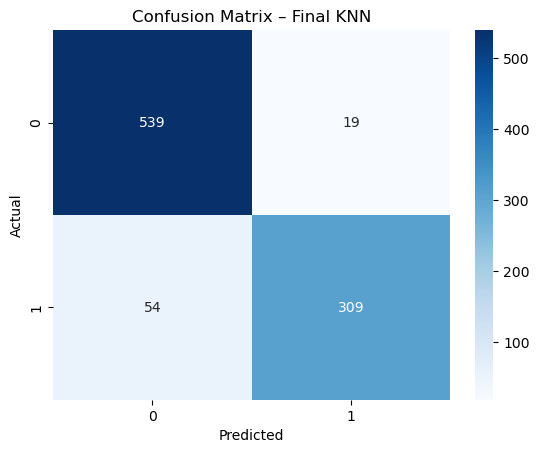

In [27]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Final KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig( "assign2_12.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


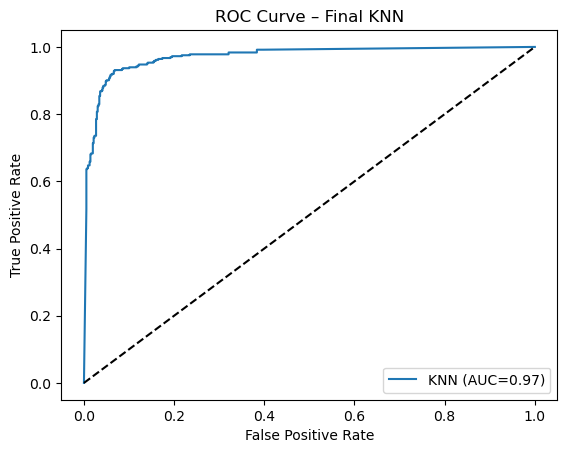

In [28]:
#ROC Curve For KNN
y_prob_knn = knn_final.predict_proba(X_test_mm)[:, 1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.2f})")
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Final KNN")
plt.legend()
plt.savefig( "assign2_13.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [29]:
best_params = grid.best_params_
optimal_k = best_params['n_neighbors']
#KDTree

start = time.time()
knn_kd = KNeighborsClassifier(
    n_neighbors = optimal_k,
    weights = best_params['weights'],
    metric = best_params['metric'],
    algorithm = 'kd_tree'
)

knn_kd.fit(X_train_mm, y_train)
train_time_kd = time.time() - start

start = time.time()
y_pred_kd = knn_kd.predict(X_test_mm)
pred_time_kd = time.time() - start


In [30]:
acc_kd, prec_kd, rec_kd, f1_kd, sp, fpr, cm = compute_metrics(y_test, y_pred_kd)

print("Final KDTree Metrics")
print("Accuracy:", acc_kd)
print("Precision:", prec_kd)
print("Recall:", rec_kd)
print("F1 Score:", f1_kd)
print("Specificity:", sp)
print("False Positive Rate:", fpr)
print("Training Time:", train_time)
print("Prediction Time:", pred_time)


Final KDTree Metrics
Accuracy: 0.9207383279044516
Precision: 0.9420731707317073
Recall: 0.8512396694214877
F1 Score: 0.894356005788712
Specificity: 0.9659498207885304
False Positive Rate: 0.034050179211469536
Training Time: 0.003858804702758789
Prediction Time: 0.04840230941772461


In [31]:
#BALL TREE
best_params = rand.best_params_
optimal_k = best_params['n_neighbors']
start = time.time()

knn_bt = KNeighborsClassifier(
    n_neighbors = optimal_k,
    weights = best_params['weights'],
    metric = best_params['metric'],
    algorithm = 'ball_tree'
)

knn_bt.fit(X_train_mm, y_train)
train_time_bt = time.time() - start

start = time.time()
y_pred_bt = knn_bt.predict(X_test_scaled)
pred_time_bt = time.time() - start


In [32]:
acc_bt, prec_bt, rec_bt, f1_bt, sp, fpr, cm = compute_metrics(y_test, y_pred_bt)

print("Final BallTree Metrics")
print("Accuracy:", acc_bt)
print("Precision:", prec_bt)
print("Recall:", rec_bt)
print("F1 Score:", f1_bt)
print("Specificity:", sp)
print("False Positive Rate:", fpr)
print("Training Time:", train_time)
print("Prediction Time:", pred_time)


Final BallTree Metrics
Accuracy: 0.9218241042345277
Precision: 0.9266862170087976
Recall: 0.8705234159779615
F1 Score: 0.8977272727272727
Specificity: 0.9551971326164874
False Positive Rate: 0.044802867383512544
Training Time: 0.003858804702758789
Prediction Time: 0.04840230941772461


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


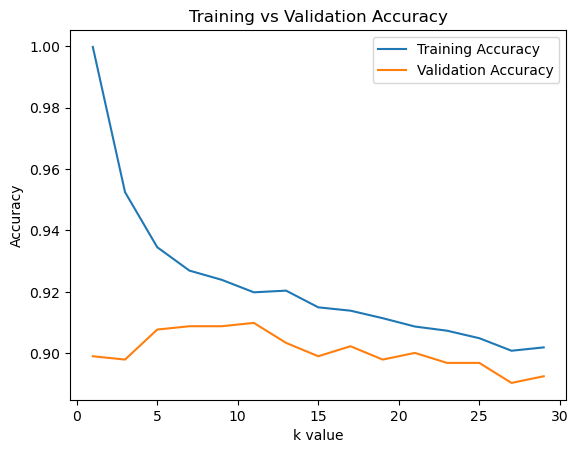

In [33]:
train_acc = []
val_acc = []

k_values = range(1, 31, 2)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_mm, y_train)
    train_acc.append(knn.score(X_train_mm, y_train))
    val_acc.append(knn.score(X_test_mm, y_test))

plt.plot(k_values, train_acc, label='Training Accuracy')
plt.plot(k_values, val_acc, label='Validation Accuracy')

plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.savefig( "assign2_14.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()


In [34]:
#Cross Validation Scores

gnb_scores = cross_val_score(
    GaussianNB(),
    X_standardized,
    y_train,
    cv = skf,
    scoring = 'accuracy'
)
mnb_scores = cross_val_score(
    MultinomialNB(),
    X_train,
    y_train,
    cv = skf,
    scoring = 'accuracy'
)
bnb_scores = cross_val_score(
    BernoulliNB(),
    X_train,
    y_train,
    cv = skf,
    scoring = 'accuracy'
)
knn_kd_scores = cross_val_score(
    knn_kd,
    X_train_mm,
    y_train,
    cv = skf,
    scoring = 'accuracy'
)
knn_bt_scores = cross_val_score(
    knn_bt,
    X_train_mm,
    y_train,
    cv = skf,
    scoring = 'accuracy'
)


In [35]:
#ONE WAY ANOVA TEST
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    gnb_scores,
    mnb_scores,
    bnb_scores,
    knn_kd_scores,
    knn_bt_scores
)

print("F-statistic:", f_stat)
print("p-value:", p_value)


F-statistic: 50.09284543965044
p-value: 3.825993556879537e-10


In [36]:
print("Gaussian NB Mean Accuracy:", gnb_scores.mean())
print("Multinomial NB Mean Accuracy:", mnb_scores.mean())
print("Bernoulli NB Mean Accuracy:", bnb_scores.mean())
print("KNN KDTree Mean Accuracy:", knn_kd_scores.mean())
print("KNN BallTree Mean Accuracy:", knn_bt_scores.mean())


Gaussian NB Mean Accuracy: 0.8144021739130436
Multinomial NB Mean Accuracy: 0.8850543478260869
Bernoulli NB Mean Accuracy: 0.8899456521739131
KNN KDTree Mean Accuracy: 0.9252717391304348
KNN BallTree Mean Accuracy: 0.9241847826086957


In [37]:
best_model = max(
    [
        ("Gaussian NB", gnb_scores.mean()),
        ("Multinomial NB", mnb_scores.mean()),
        ("Bernoulli NB", bnb_scores.mean()),
        ("KNN KDTree", knn_kd_scores.mean()),
        ("KNN BallTree", knn_bt_scores.mean())
    ],
    key=lambda x: x[1]
)

print("Best Model:", best_model)


Best Model: ('KNN KDTree', np.float64(0.9252717391304348))


In [38]:
#Thus, the Best Model is KNN KD TREE